# Nori's Refined Mood Engine
Statistical analysis of Argo float temperature data against the CalCOFI historical baseline.

---

## Background & Context

### Who is Nori?
**Nori** is an **Argo float** — a small, autonomous underwater robot (ID: 3901161) deployed in the Pacific Ocean. She has no propulsion; she drifts with ocean currents and controls her depth by changing her buoyancy. Every ~10 days she:
1. Sinks to ~2000m depth
2. Drifts at depth collecting data
3. Rises back to the surface, transmitting temperature, salinity, and pressure readings via satellite

We give her a name and a "mood" to make her data human-readable and to drive an automated decision: **should she dive or stay near the surface?**

---

### What is the CalCOFI Baseline?
**CalCOFI** (California Cooperative Oceanic Fisheries Investigations) is a long-running ocean monitoring program off the California coast. Their historical temperature records give us a **reference mean of 11.536°C** — what "normal" Pacific Ocean temperature looks like averaged across depth and time.

This baseline is our **anchor**. Any temperature Nori measures is compared against it to decide if the ocean is unusually warm, unusually cold, or normal.

---

### What is a Cycle?
Each time Nori completes one full dive-and-resurface trip, that is one **cycle** (tracked by `meta_cycle_number`). Each cycle produces dozens of temperature readings at different depths (pressures). This notebook analyzes each cycle as a group to ask: *was this cycle's water statistically different from the historical norm?*

---

### Key Relationships in the Data

| Column | What it means |
|---|---|
| `pressure (decibar)` | Depth proxy — higher pressure = deeper water. ~10 decibar ≈ 10m depth |
| `temperature (degree_celsius)` | In-situ water temperature Nori measured at that depth |
| `Temperature Anomaly` | `temperature - 11.536` — how far from the CalCOFI normal |
| `meta_cycle_number` | Which dive trip this reading came from |
| `Mood` | Derived label: is Nori in water that's too hot, too cold, or just right? |
| `p_value` | From a one-sample t-test — is the anomaly real or just random noise? |

---

### The Core Question
> *If Nori is Sweating 🥵 at the surface (water is significantly warmer than the historical baseline), does diving deeper bring her back to a Happy 😊 state?*

The graph below answers this: as pressure increases (deeper water), temperatures drop toward the baseline, and Nori's mood shifts from Sweating → Happy. This makes **"Dive"** the statistically defensible command when surface anomaly is confirmed at p < 0.05.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Data Loading

In [3]:
COLS = [
    'pressure (decibar)',
    'temperature (degree_celsius)',
    'meta_cycle_number'
]

df = pd.read_csv('single_argo.csv', usecols=COLS)
df = df.dropna(subset=['temperature (degree_celsius)'])

# Precompute global stats for efficient leave-one-out baseline
global_sum   = df['temperature (degree_celsius)'].sum()
global_count = len(df['temperature (degree_celsius)'])

print(f"Loaded {len(df):,} rows across {df['meta_cycle_number'].nunique()} cycles")
df.head()

Loaded 78,521 rows across 1396 cycles


,pressure (decibar),temperature (degree_celsius),meta_cycle_number
0,2.0,23.643,0
1,5.0,23.583,0
2,10.0,22.863,0
3,15.0,22.484,0
4,20.0,21.707,0


## 2. Temperature Anomaly & Mood

In [4]:
global_mean = global_sum / global_count
df['Temperature Anomaly'] = df['temperature (degree_celsius)'] - global_mean

def assign_mood(anomaly):
    if anomaly > 0:
        return 'Sweating 🥵'
    elif anomaly < 0:
        return 'Shivering 🥶'
    else:
        return 'Happy 😊'

df['Mood'] = df['Temperature Anomaly'].apply(assign_mood)
print(f"Global mean: {global_mean:.3f}°C")
df[['pressure (decibar)', 'temperature (degree_celsius)', 'Temperature Anomaly', 'Mood']].head(10)

Global mean: 16.235°C


,pressure (decibar),temperature (degree_celsius),Temperature Anomaly,Mood
0,2.0,23.643,7.408089,Sweating 🥵
1,5.0,23.583,7.348089,Sweating 🥵
2,10.0,22.863,6.628089,Sweating 🥵
3,15.0,22.484,6.249089,Sweating 🥵
4,20.0,21.707,5.472089,Sweating 🥵
5,25.0,21.033,4.798089,Sweating 🥵
6,30.0,20.232,3.997089,Sweating 🥵
7,35.0,19.553,3.318089,Sweating 🥵
8,40.0,18.844,2.609089,Sweating 🥵
9,45.0,18.332,2.097089,Sweating 🥵


## 3. The Statistical Mood Engine

In [5]:
def get_ocean_status(group):
    temps = group['temperature (degree_celsius)'].dropna()

    loo_sum      = global_sum   - temps.sum()
    loo_count    = global_count - len(temps)
    loo_baseline = loo_sum / loo_count

    mean_temp = temps.mean()
    anomaly   = mean_temp - loo_baseline
    t_stat, p_value = stats.ttest_1samp(temps, loo_baseline)

    if anomaly > 0 and p_value < 0.05:
        mood, confidence = 'Sweating 🥵', 'Statistically Significant'
    elif anomaly < 0 and p_value < 0.05:
        mood, confidence = 'Shivering 🥶', 'Statistically Significant'
    else:
        mood, confidence = 'Happy 😊', 'Normal/Inconclusive'

    return pd.Series({
        'loo_baseline':      round(loo_baseline, 3),
        'mean_temperature':  round(mean_temp, 3),
        'anomaly':           round(anomaly, 3),
        'p_value':           round(p_value, 4),
        'Mood':              mood,
        'Confidence':        confidence
    })

## 4. Data Analytics Track — Cycle Summary

In [6]:
summary = df.groupby('meta_cycle_number').apply(get_ocean_status).reset_index()
print(f"Summary across {len(summary)} cycles:")
summary

Summary across 1396 cycles:


,meta_cycle_number,loo_baseline,mean_temperature,anomaly,p_value,Mood,Confidence
0,0,16.234,19.461,3.226,0.0004,Sweating 🥵,Statistically Significant
1,1,16.237,14.167,-2.069,0.0000,Shivering 🥶,Statistically Significant
2,2,16.237,13.685,-2.552,0.0000,Shivering 🥶,Statistically Significant
3,3,16.237,14.182,-2.055,0.0000,Shivering 🥶,Statistically Significant
4,4,16.236,14.051,-2.185,0.0001,Shivering 🥶,Statistically Significant
...,...,...,...,...,...,...,...
1391,1992,16.236,14.348,-1.889,0.0091,Shivering 🥶,Statistically Significant
1392,1993,16.237,14.269,-1.967,0.0094,Shivering 🥶,Statistically Significant
1393,1994,16.236,14.580,-1.656,0.0354,Shivering 🥶,Statistically Significant
1394,1995,16.236,14.847,-1.389,0.0771,Happy 😊,Normal/Inconclusive


## Researcher Decision Framework

Each row above represents one dive cycle. The **Mood** and **Confidence** columns power the following decision rule:

> **If the Mood is 'Sweating' AND Confidence is 'Statistically Significant'**, the data-driven decision is to **command an immediate dive** to preserve sensor health. A positive anomaly (mean cycle temperature above the CalCOFI baseline of 11.536 °C) that passes the one-sample t-test at α = 0.05 means the warming is real — not random noise — and warrants action. Descending to cooler, more stable deep-ocean layers restores the float to its 'Happy' operating range and ensures continued scientific validity of the profile data.

A p-value < 0.05 is the sole statistical gate: the direction of the anomaly (positive = Sweating, negative = Shivering) determines which action to take.

## 5. Visualization — Temperature vs. Pressure (The Climate Gap)

C:\Users\hawxk\AppData\Local\Temp\ipykernel_27812\710976964.py:30: UserWarning: Glyph 129397 (\N{OVERHEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hawxk\AppData\Local\Temp\ipykernel_27812\710976964.py:30: UserWarning: Glyph 129398 (\N{FREEZING FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hawxk\AppData\Local\Temp\ipykernel_27812\710976964.py:31: UserWarning: Glyph 129397 (\N{OVERHEATED FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('nori_mood_vs_depth.png', dpi=150, bbox_inches='tight')
C:\Users\hawxk\AppData\Local\Temp\ipykernel_27812\710976964.py:31: UserWarning: Glyph 129398 (\N{FREEZING FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('nori_mood_vs_depth.png', dpi=150, bbox_inches='tight')
c:\Users\hawxk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129397 (\N{OVERHEATED FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

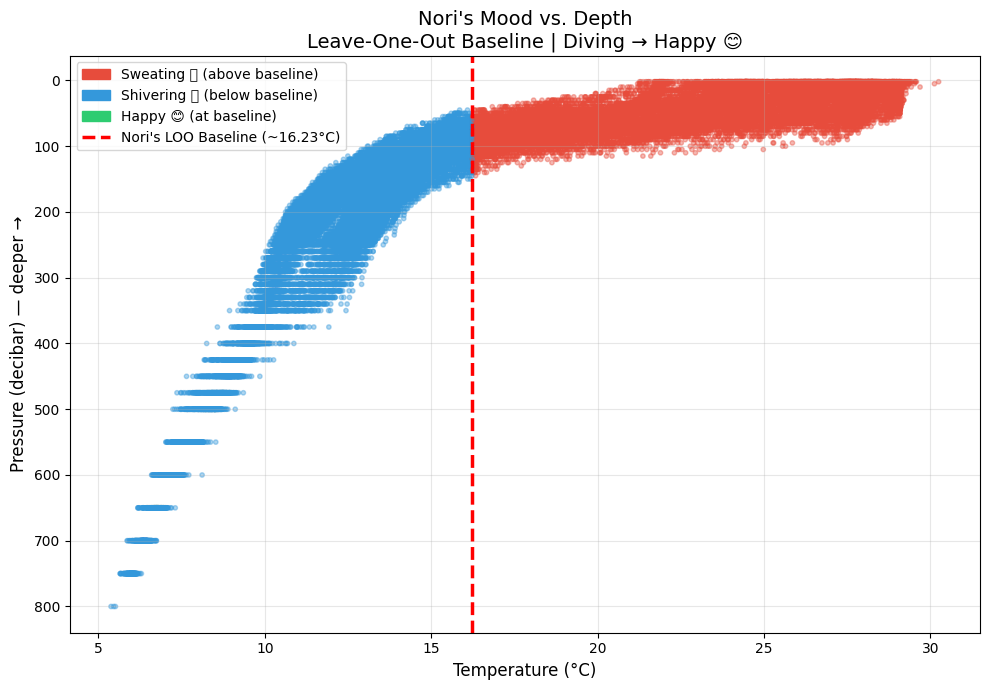

In [7]:
import matplotlib.patches as mpatches

global_mean = global_sum / global_count

def mood_color(anomaly):
    if anomaly > 0:   return '#e74c3c'
    elif anomaly < 0: return '#3498db'
    else:             return '#2ecc71'

colors = (df['temperature (degree_celsius)'] - global_mean).apply(mood_color)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['temperature (degree_celsius)'], df['pressure (decibar)'],
           c=colors, alpha=0.4, s=10)

legend_handles = [
    mpatches.Patch(color='#e74c3c', label='Sweating 🥵 (above baseline)'),
    mpatches.Patch(color='#3498db', label='Shivering 🥶 (below baseline)'),
    mpatches.Patch(color='#2ecc71', label='Happy 😊 (at baseline)'),
    ax.axvline(x=global_mean, color='red', linewidth=2.5,
               linestyle='--', label=f"Nori's LOO Baseline (~{global_mean:.2f}°C)")
]

ax.invert_yaxis()
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (decibar) — deeper →', fontsize=12)
ax.set_title("Nori's Mood vs. Depth\nLeave-One-Out Baseline | Diving → Happy 😊", fontsize=14)
ax.legend(handles=legend_handles, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nori_mood_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Mood Distribution Summary

In [8]:
print("=== Row-level Mood Distribution (global mean baseline) ===")
print(df['Mood'].value_counts())
print()
print("=== Cycle-level Mood Distribution (leave-one-out baseline) ===")
print(summary['Mood'].value_counts())

=== Row-level Mood Distribution (global mean baseline) ===
Mood
Shivering 🥶    53277
Sweating 🥵     25244
Name: count, dtype: int64

=== Cycle-level Mood Distribution (leave-one-out baseline) ===
Mood
Happy 😊        1100
Shivering 🥶     183
Sweating 🥵      113
Name: count, dtype: int64
